<a href="https://colab.research.google.com/github/mehrshad-sdtn/DeepLearning/blob/master/Playground/Autoencoder_Deep_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment

In [2]:
################################## utils.py ####################################
def imshow(img, title):
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), interpolation='nearest')
    plt.title(title)
    plt.show()

In [5]:
################################ models.py ###################################
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 2000),
            nn.ReLU(),
            nn.Linear(2000, 10),

        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(10, 2000),
            nn.ReLU(),
            nn.Linear(2000, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
      x = x.view(-1, 28 * 28)
      encoded = self.encoder(x)
      decoded = self.decoder(encoded)
      decoded = decoded.view(-1, 1, 28, 28)
      return encoded, decoded



def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs):
  for epoch in range(num_epochs):
    for data in train_loader:
      img, _ = data
      img = img.to(device)

      # Forward
      _, reconstructed = model(img)
      loss = criterion(reconstructed, img)

      # Backward
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
train_autoencoder(model, train_loader, criterion, optimizer, num_epochs=30)

Epoch [1/30], Loss: 0.0234
Epoch [2/30], Loss: 0.0213
Epoch [3/30], Loss: 0.0163
Epoch [4/30], Loss: 0.0144
Epoch [5/30], Loss: 0.0125
Epoch [6/30], Loss: 0.0135
Epoch [7/30], Loss: 0.0104
Epoch [8/30], Loss: 0.0140
Epoch [9/30], Loss: 0.0110
Epoch [10/30], Loss: 0.0121
Epoch [11/30], Loss: 0.0112
Epoch [12/30], Loss: 0.0104
Epoch [13/30], Loss: 0.0102
Epoch [14/30], Loss: 0.0103
Epoch [15/30], Loss: 0.0112
Epoch [16/30], Loss: 0.0130
Epoch [17/30], Loss: 0.0114
Epoch [18/30], Loss: 0.0091
Epoch [19/30], Loss: 0.0097
Epoch [20/30], Loss: 0.0104
Epoch [21/30], Loss: 0.0099
Epoch [22/30], Loss: 0.0104
Epoch [23/30], Loss: 0.0087
Epoch [24/30], Loss: 0.0099
Epoch [25/30], Loss: 0.0096
Epoch [26/30], Loss: 0.0100
Epoch [27/30], Loss: 0.0095
Epoch [28/30], Loss: 0.0084
Epoch [29/30], Loss: 0.0091
Epoch [30/30], Loss: 0.0074


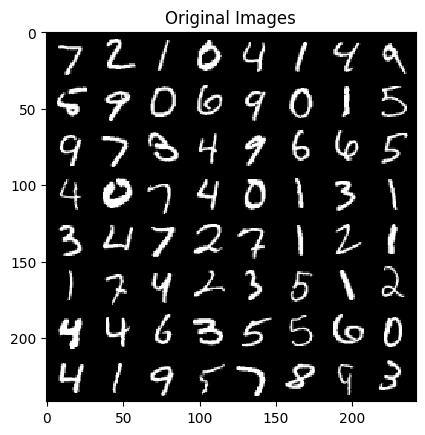

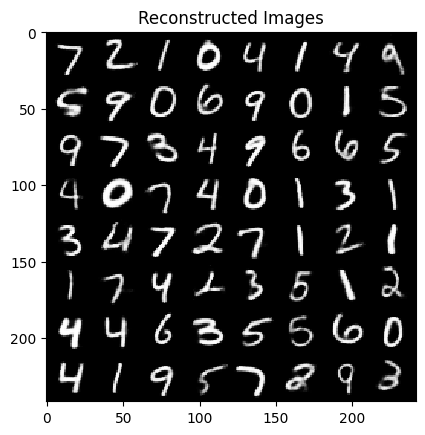

In [15]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)


encoded, reconstructed = model(images)
imshow(torchvision.utils.make_grid(images.cpu()), 'Original Images')
imshow(torchvision.utils.make_grid(reconstructed.detach().cpu()), 'Reconstructed Images')

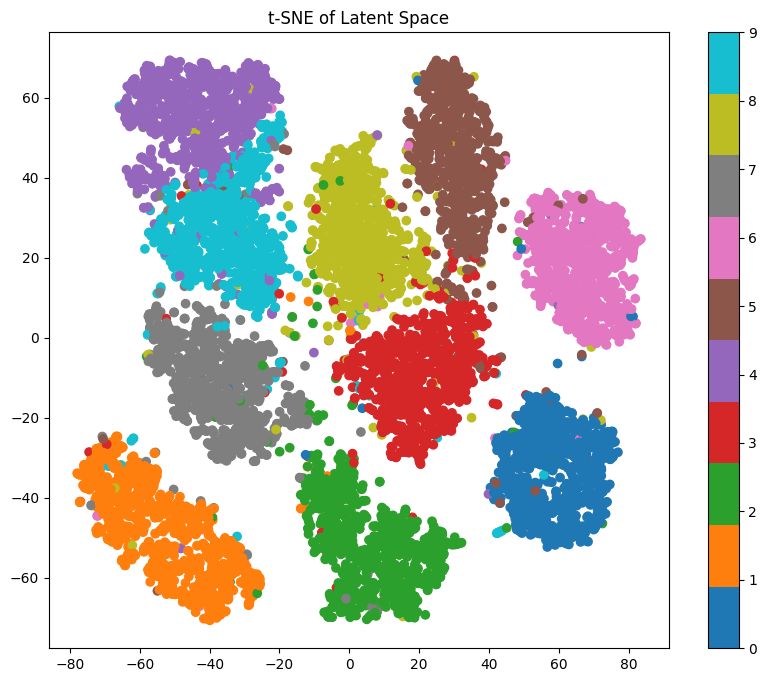

In [16]:
latent_vectors = []
latent_labels = []
model.eval()

with torch.no_grad():
    for data in test_loader:
        img, labels = data
        img = img.to(device)
        encoded, _ = model(img)
        latent_vectors.append(encoded.cpu().numpy())
        latent_labels.append(labels.numpy())

latent_vectors = np.concatenate(latent_vectors)
latent_labels = np.concatenate(latent_labels)

# Use t-SNE to reduce dimensionality
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=latent_labels, cmap='tab10')
plt.colorbar(scatter)
plt.title('t-SNE of Latent Space')
plt.show()

In [17]:
kmeans = KMeans(n_clusters=10, n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(latent_vectors)

# Map cluster labels to true labels to maximize accuracy
def cluster_accuracy(y_true, y_pred):
    assert y_true.size == y_pred.size
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_true.size):
        w[y_pred[i], y_true[i]] += 1
    ind = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(*ind)]) / y_true.size

accuracy = cluster_accuracy(latent_labels, cluster_labels)
print(f'Clustering Accuracy: {accuracy * 100:.2f}')

Clustering Accuracy: 69.75
